In [3]:
"""
=============================================================
  PARCL – Property Buyer Segmentation  |  Data Science Pipeline
=============================================================
Steps: Data Cleaning → EDA → Feature Engineering → Scaling →
       Clustering (K-Means + Hierarchical) → Interpretation
"""

# ─────────────────────────────────────────────────────────────
# 0. IMPORTS & GLOBAL STYLE
# ─────────────────────────────────────────────────────────────
import warnings, re
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from   matplotlib.patches  import FancyBboxPatch
from   matplotlib.colors   import LinearSegmentedColormap

from sklearn.preprocessing  import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster        import KMeans, AgglomerativeClustering
from sklearn.metrics        import silhouette_score, davies_bouldin_score
from sklearn.decomposition  import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance  import cdist

In [4]:
# ── Colour palette ────────────────────────────────────────────
PARCL_PALETTE = ["#4361EE", "#F72585", "#7209B7", "#3A0CA3",
                 "#4CC9F0", "#F3722C", "#90BE6D", "#43AA8B"]

CLUSTER_PALETTE = {
    "Global Investors":   "#4361EE",
    "First-Time Buyers":  "#F72585",
    "Corporate Buyers":   "#7209B7",
    "Luxury Investors":   "#F3722C",
}

plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "#0D1117",
    "axes.facecolor":    "#161B22",
    "axes.edgecolor":    "#30363D",
    "axes.labelcolor":   "#C9D1D9",
    "axes.titlecolor":   "#E6EDF3",
    "xtick.color":       "#8B949E",
    "ytick.color":       "#8B949E",
    "text.color":        "#C9D1D9",
    "grid.color":        "#21262D",
    "grid.linestyle":    "--",
    "legend.facecolor":  "#161B22",
    "legend.edgecolor":  "#30363D",
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

OUTPUT = "outputs"

def save(fig, name):
    fig.savefig(f"{OUTPUT}/{name}.png", bbox_inches="tight", dpi=130,
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  ✓  saved {name}.png")

In [5]:
# ─────────────────────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 0 — Loading Data")
print("="*60)

clients = pd.read_csv("Dataset/clients.csv")
props   = pd.read_csv("Dataset/properties.csv")

print(f"  Clients  : {clients.shape[0]:,} rows × {clients.shape[1]} cols")
print(f"  Properties: {props.shape[0]:,} rows × {props.shape[1]} cols")


  STEP 0 — Loading Data
  Clients  : 2,000 rows × 12 cols
  Properties: 10,000 rows × 9 cols


In [6]:
# ─────────────────────────────────────────────────────────────
# 2. DATA CLEANING
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 1 — Data Cleaning")
print("="*60)

# ── Clients ──────────────────────────────────────────────────
clients = clients.drop_duplicates(subset="client_id")

# Standardise categorical labels (strip whitespace, title-case)
for col in ["client_type","gender","country","region",
            "acquisition_purpose","referral_channel","loan_applied"]:
    clients[col] = clients[col].str.strip().str.title()

# Parse date_of_birth (mixed formats) → age
clients["dob"] = pd.to_datetime(clients["date_of_birth"],
                                dayfirst=False, errors="coerce")
today           = pd.Timestamp("2024-01-01")
clients["age"]  = ((today - clients["dob"]).dt.days / 365.25).round(1)

# Drop rows where age is implausible (<10 or >110)
clients = clients[(clients["age"] >= 10) & (clients["age"] <= 110)]

# ── Properties ───────────────────────────────────────────────
# Clean sale_price (strip $ and commas)
props["sale_price"] = (props["sale_price"]
                       .astype(str)
                       .str.replace(r"[\$,]", "", regex=True)
                       .astype(float))

# Parse transaction_date
props["txn_date"] = pd.to_datetime(props["transaction_date"],
                                   errors="coerce")

# Normalise unit_category
props["unit_category"] = props["unit_category"].str.strip().str.title()

# ── Merge (clients who made a purchase) ─────────────────────
merged = clients.merge(
    props[props["listing_status"]=="Sold"][
        ["client_ref","sale_price","floor_area_sqft","unit_category","tower_number"]
    ].rename(columns={"client_ref":"client_id"}),
    on="client_id", how="left"
)

# Aggregate property-level info per client
prop_agg = (props[props["listing_status"]=="Sold"]
            .rename(columns={"client_ref":"client_id"})
            .groupby("client_id")
            .agg(
                num_properties   = ("listing_id",   "count"),
                total_investment = ("sale_price",    "sum"),
                avg_unit_area    = ("floor_area_sqft","mean"),
            ).reset_index())

df = clients.merge(prop_agg, on="client_id", how="left")
df["num_properties"]   = df["num_properties"].fillna(0)
df["total_investment"] = df["total_investment"].fillna(0)
df["avg_unit_area"]    = df["avg_unit_area"].fillna(df["avg_unit_area"].median())

print(f"  After cleaning – clients : {df.shape[0]:,}")
print(f"  Clients with purchases   : {(df['num_properties']>0).sum():,}")


  STEP 1 — Data Cleaning
  After cleaning – clients : 855
  Clients with purchases   : 855



  STEP 2 — EDA Visualisations


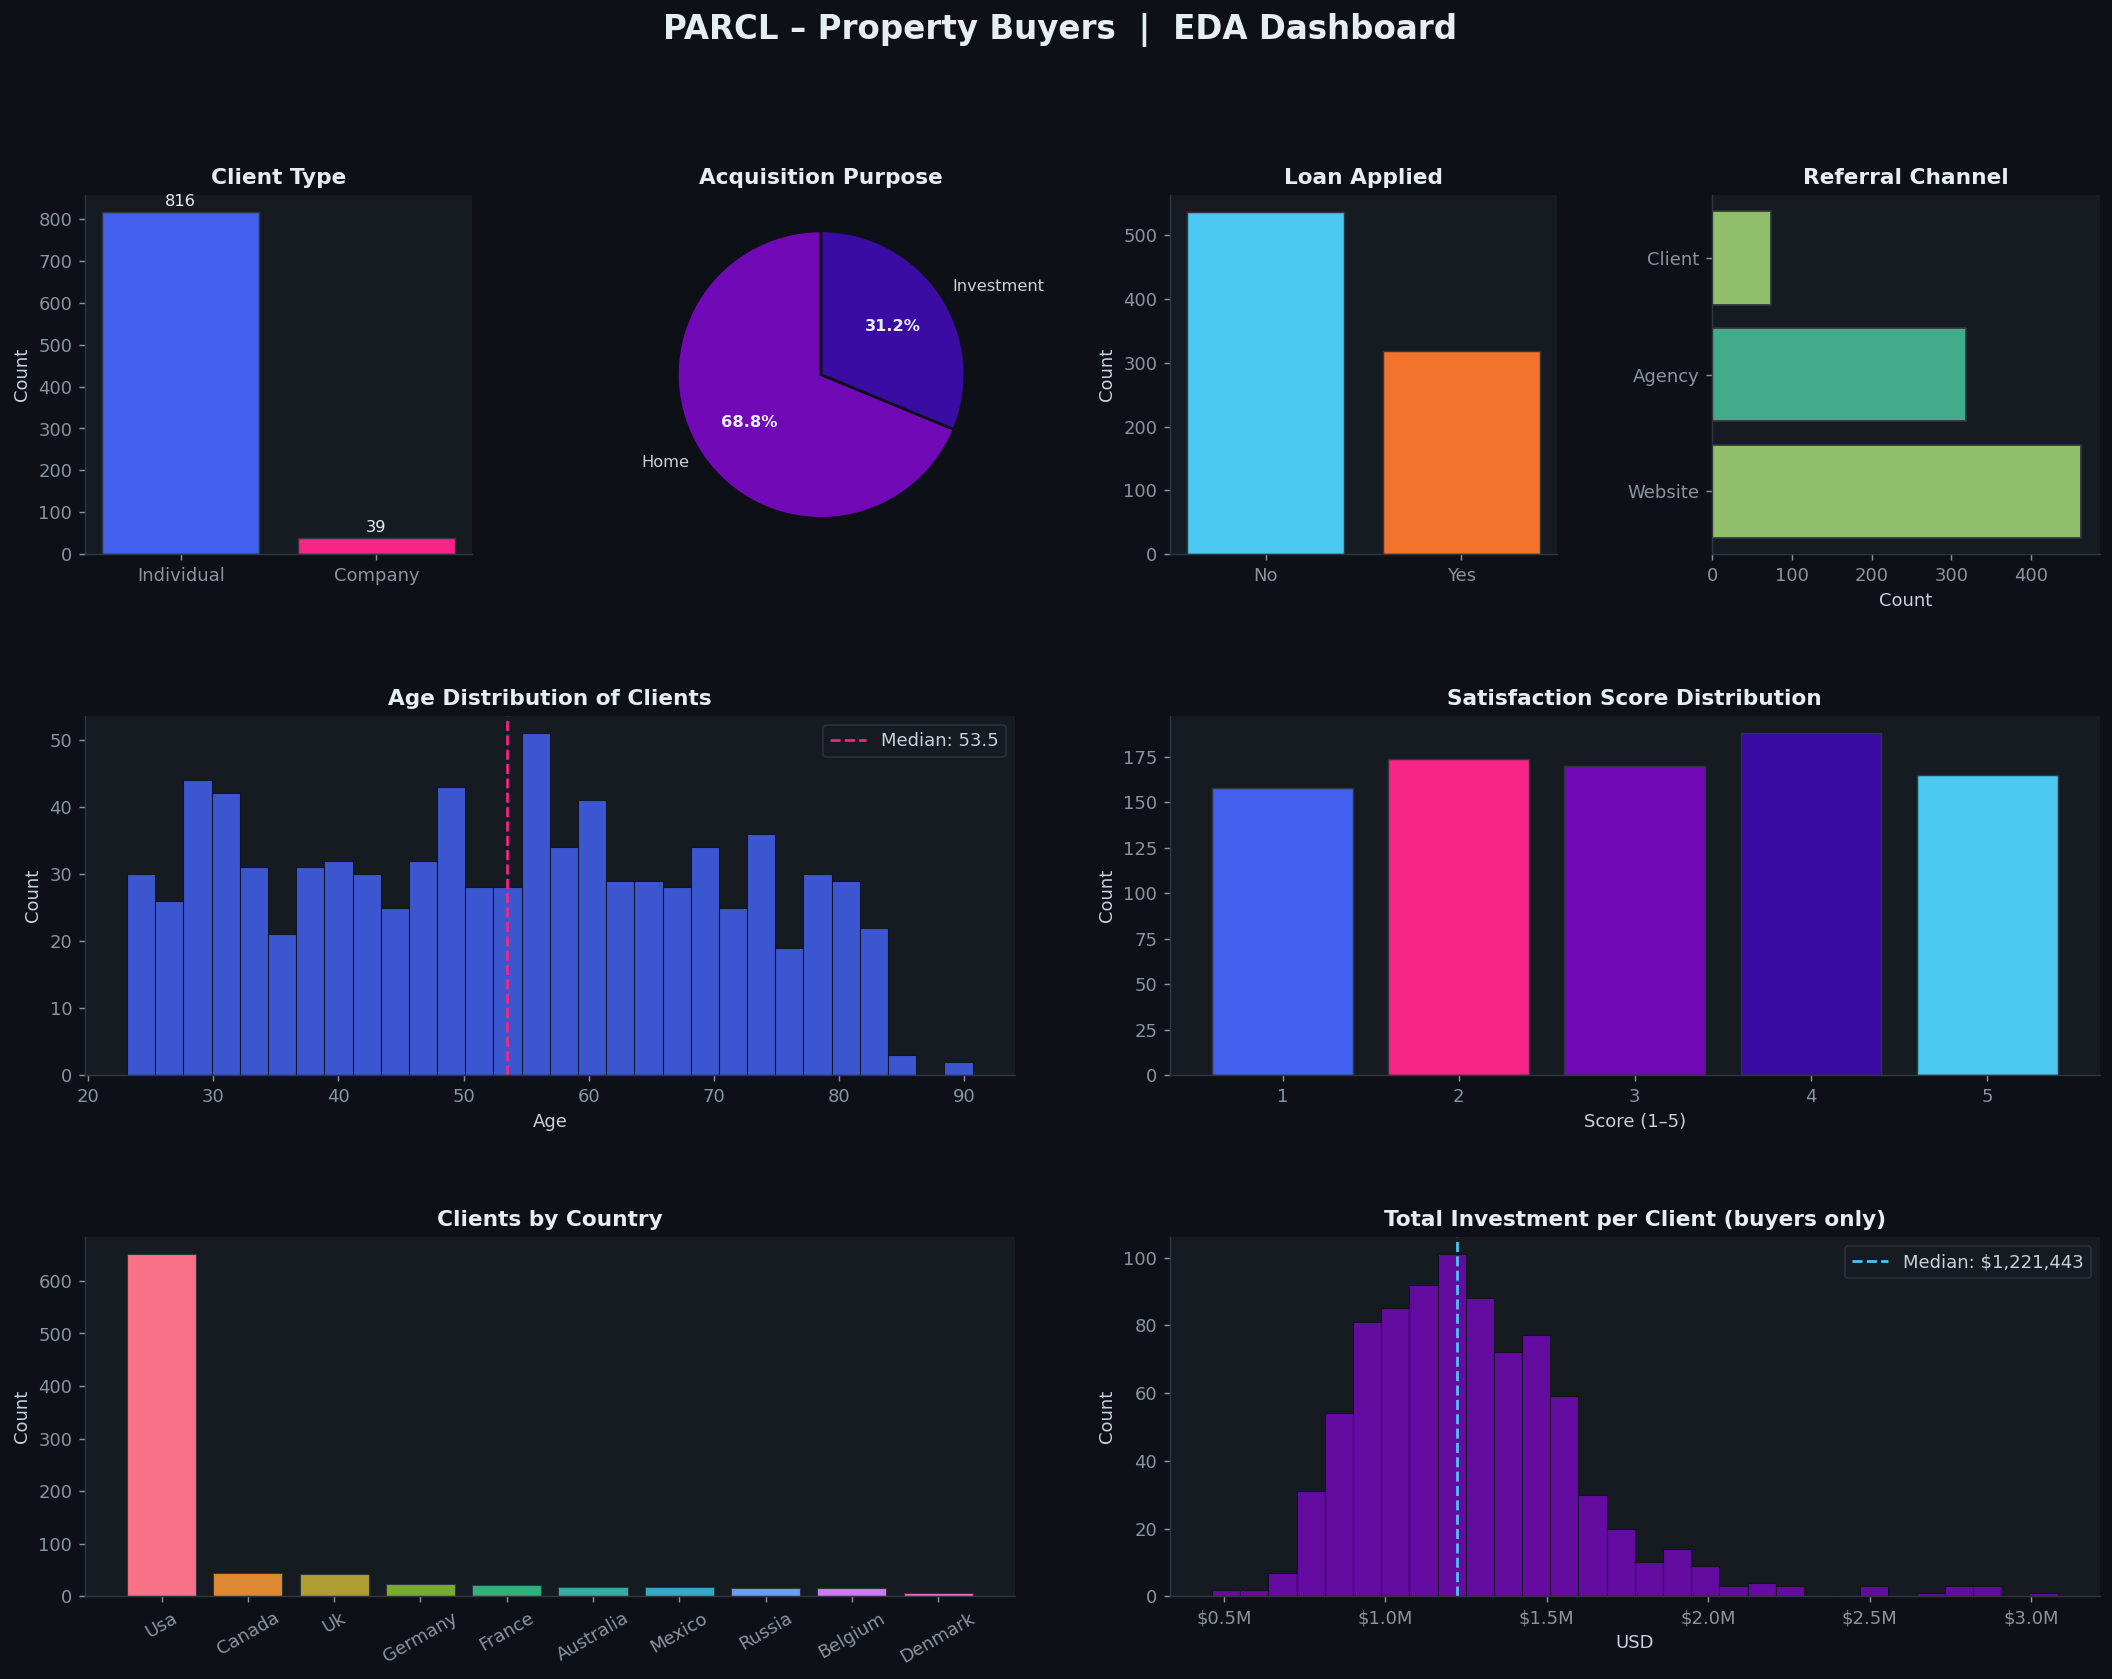

  ✓  saved 01_eda_overview.png


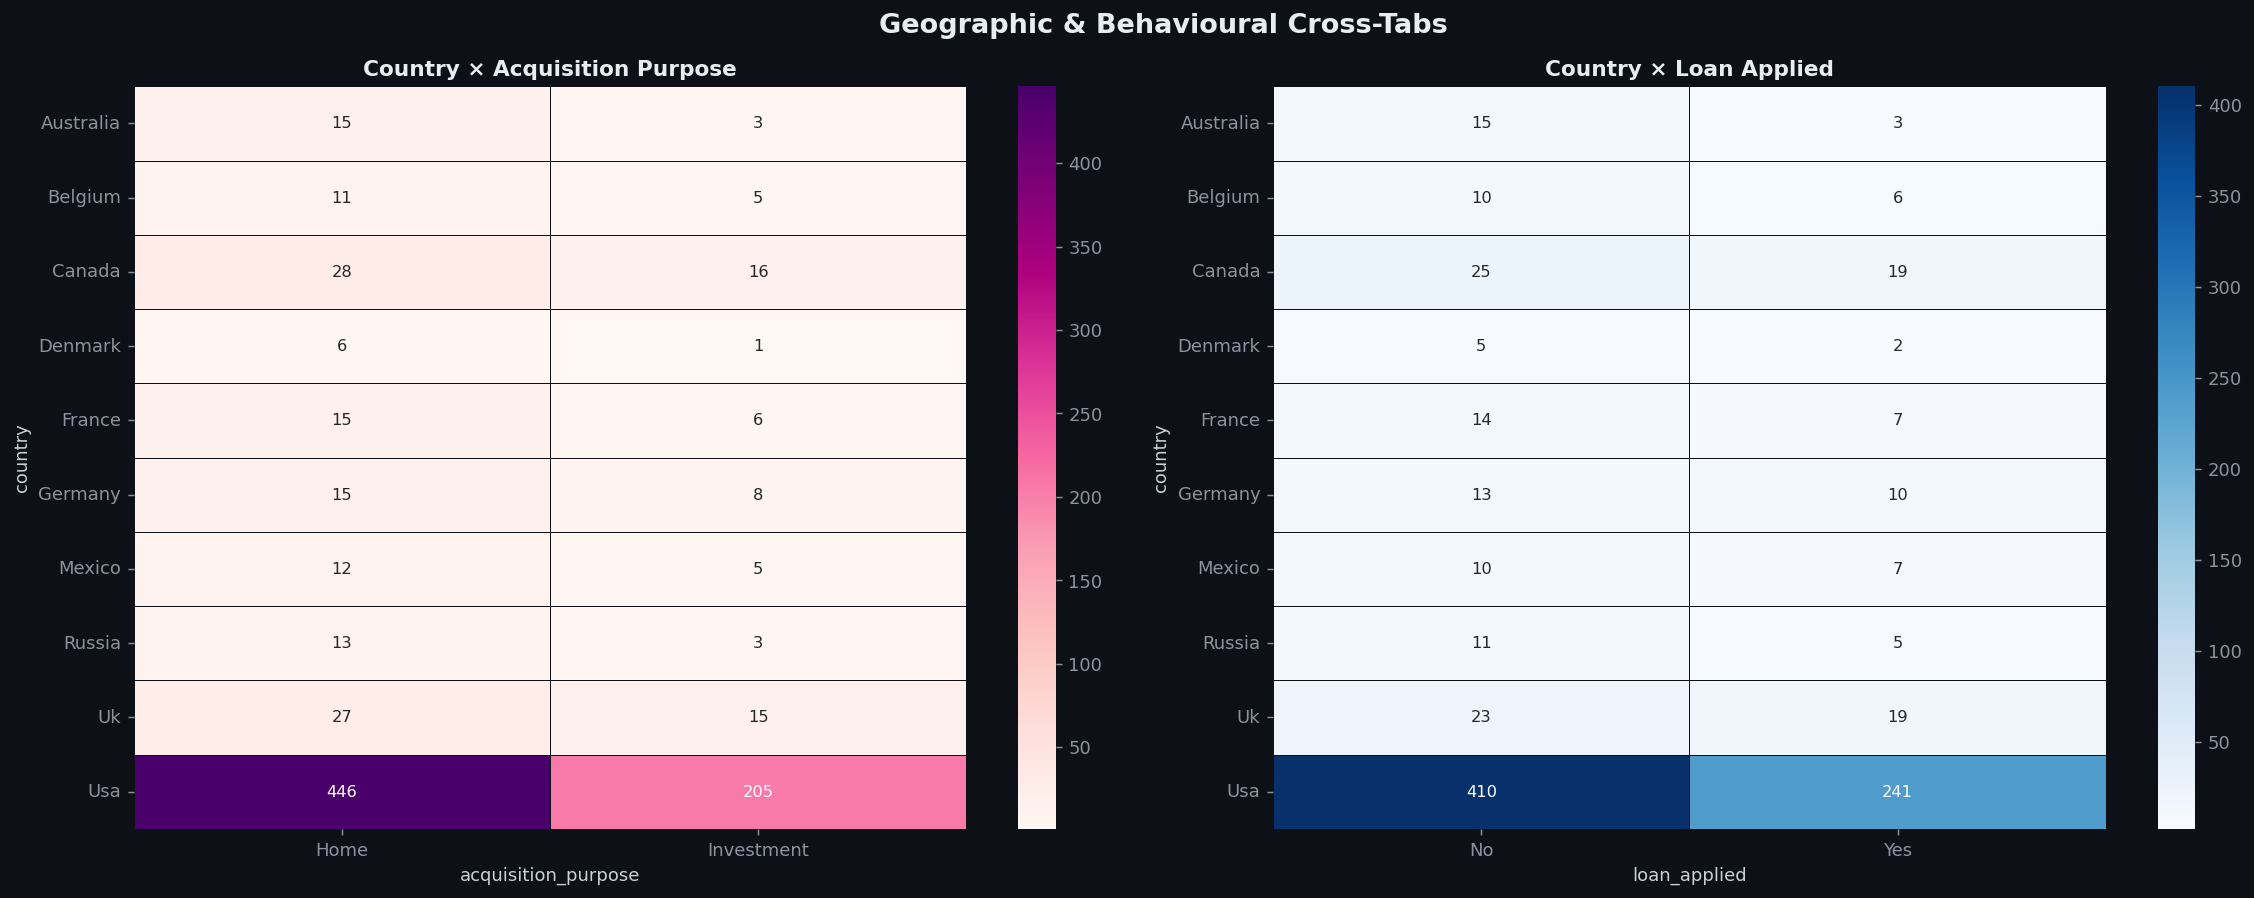

  ✓  saved 02_eda_geo_crosstabs.png


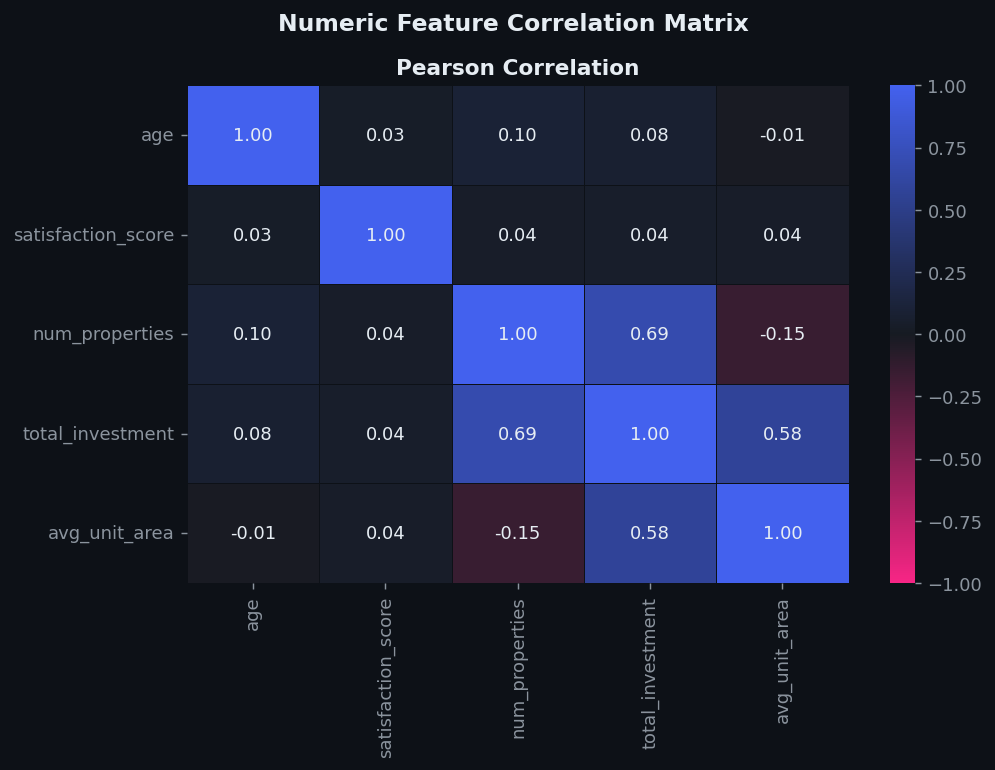

  ✓  saved 03_eda_correlation.png


In [15]:
# ─────────────────────────────────────────────────────────────
# 3. EXPLORATORY DATA ANALYSIS  (EDA)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 2 — EDA Visualisations")
print("="*60)

# ── 3A. Overview dashboard ───────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle("PARCL – Property Buyers  |  EDA Dashboard",
             fontsize=18, fontweight="bold", color="#E6EDF3", y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.4)

# 1. Client type distribution
ax1 = fig.add_subplot(gs[0, 0])
ct   = df["client_type"].value_counts()
bars = ax1.bar(ct.index, ct.values, color=PARCL_PALETTE[:2], edgecolor="#30363D", linewidth=0.8)
ax1.set_title("Client Type", fontweight="bold")
ax1.set_ylabel("Count")
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+8,
             f"{b.get_height():,}", ha="center", va="bottom", fontsize=9, color="#E6EDF3")

# 2. Acquisition purpose
ax2 = fig.add_subplot(gs[0, 1])
ap   = df["acquisition_purpose"].value_counts()
wedges, texts, autotexts = ax2.pie(
    ap.values, labels=ap.index, autopct="%1.1f%%",
    colors=PARCL_PALETTE[2:4], startangle=90,
    textprops={"color":"#C9D1D9", "fontsize":9},
    wedgeprops={"edgecolor":"#0D1117","linewidth":1.5}
)
for at in autotexts:
    at.set_color("#E6EDF3"); at.set_fontweight("bold")
ax2.set_title("Acquisition Purpose", fontweight="bold")

# 3. Loan applied
ax3 = fig.add_subplot(gs[0, 2])
la   = df["loan_applied"].value_counts()
ax3.bar(la.index, la.values, color=[PARCL_PALETTE[4], PARCL_PALETTE[5]],
        edgecolor="#30363D", linewidth=0.8)
ax3.set_title("Loan Applied", fontweight="bold")
ax3.set_ylabel("Count")

# 4. Referral channel
ax4 = fig.add_subplot(gs[0, 3])
rc   = df["referral_channel"].value_counts()
ax4.barh(rc.index, rc.values, color=PARCL_PALETTE[6:9], edgecolor="#30363D")
ax4.set_title("Referral Channel", fontweight="bold")
ax4.set_xlabel("Count")

# 5. Age distribution
ax5 = fig.add_subplot(gs[1, :2])
ax5.hist(df["age"].dropna(), bins=30, color="#4361EE", edgecolor="#0D1117",
         alpha=0.85, linewidth=0.6)
ax5.axvline(df["age"].median(), color="#F72585", linestyle="--", linewidth=1.5,
            label=f"Median: {df['age'].median():.1f}")
ax5.set_title("Age Distribution of Clients", fontweight="bold")
ax5.set_xlabel("Age"); ax5.set_ylabel("Count")
ax5.legend()

# 6. Satisfaction score
ax6 = fig.add_subplot(gs[1, 2:])
ss   = df["satisfaction_score"].value_counts().sort_index()
ax6.bar(ss.index, ss.values, color=PARCL_PALETTE, edgecolor="#30363D", linewidth=0.8)
ax6.set_title("Satisfaction Score Distribution", fontweight="bold")
ax6.set_xlabel("Score (1–5)"); ax6.set_ylabel("Count")


# 7. Country breakdown
ax7 = fig.add_subplot(gs[2, :2])
co   = df["country"].value_counts()
ax7.bar(co.index, co.values, color=sns.color_palette("husl", len(co)),
        edgecolor="#30363D", linewidth=0.6)
ax7.set_title("Clients by Country", fontweight="bold")
ax7.set_ylabel("Count")
ax7.tick_params(axis="x", rotation=30)


# 8. Total investment histogram
ax8 = fig.add_subplot(gs[2, 2:])
inv = df[df["total_investment"]>0]["total_investment"]
ax8.hist(inv, bins=30, color="#7209B7", edgecolor="#0D1117", alpha=0.85, linewidth=0.6)
ax8.axvline(inv.median(), color="#4CC9F0", linestyle="--", linewidth=1.5,
            label=f"Median: ${inv.median():,.0f}")
ax8.set_title("Total Investment per Client (buyers only)", fontweight="bold")
ax8.set_xlabel("USD"); ax8.set_ylabel("Count")
ax8.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
ax8.legend()
plt.tight_layout()
plt.show()

save(fig, "01_eda_overview")

# ── 3B. Geographic & cross-tab heatmap ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Geographic & Behavioural Cross-Tabs", fontsize=15,
             fontweight="bold", color="#E6EDF3")

# Heatmap: country × acquisition_purpose
ct_heat = pd.crosstab(df["country"], df["acquisition_purpose"])
sns.heatmap(ct_heat, annot=True, fmt="d", cmap="RdPu", linewidths=0.5,
            linecolor="#0D1117", ax=axes[0], annot_kws={"fontsize":9})
axes[0].set_title("Country × Acquisition Purpose", fontweight="bold")
axes[0].tick_params(axis="x", rotation=0)

# Heatmap: country × loan_applied
lt_heat = pd.crosstab(df["country"], df["loan_applied"])
sns.heatmap(lt_heat, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            linecolor="#0D1117", ax=axes[1], annot_kws={"fontsize":9})
axes[1].set_title("Country × Loan Applied", fontweight="bold")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()
save(fig, "02_eda_geo_crosstabs")

# ── 3C. Correlation matrix of numerics ──────────────────────
num_cols = ["age","satisfaction_score","num_properties","total_investment","avg_unit_area"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Numeric Feature Correlation Matrix", fontsize=13, fontweight="bold",
             color="#E6EDF3")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = LinearSegmentedColormap.from_list("parcl", ["#F72585","#161B22","#4361EE"], N=256)
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="#0D1117", ax=ax,
            annot_kws={"fontsize":10, "color":"#E6EDF3"})
ax.set_title("Pearson Correlation", fontweight="bold")
fig.tight_layout()
plt.show()
save(fig, "03_eda_correlation")

In [16]:
# ─────────────────────────────────────────────────────────────
# 4. FEATURE ENGINEERING & ENCODING
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 3 — Feature Encoding")
print("="*60)

enc_df = df.copy()

# Label encode binary / ordinal
le = LabelEncoder()
enc_df["loan_applied_enc"]  = le.fit_transform(enc_df["loan_applied"])        # No=0, Yes=1
enc_df["client_type_enc"]   = le.fit_transform(enc_df["client_type"])         # Company=0, Individual=1
enc_df["acq_purpose_enc"]   = le.fit_transform(enc_df["acquisition_purpose"]) # Home=0, Investment=1

# One-Hot encode multi-class categoricals
ohe_cols = ["referral_channel", "country"]
ohe_df   = pd.get_dummies(enc_df[ohe_cols], prefix=ohe_cols, drop_first=False).astype(int)

# Assemble feature matrix
feature_cols = ["age","satisfaction_score","num_properties",
                "total_investment","avg_unit_area",
                "loan_applied_enc","client_type_enc","acq_purpose_enc"]

X_raw = pd.concat([enc_df[feature_cols].reset_index(drop=True),
                   ohe_df.reset_index(drop=True)], axis=1)
X_raw = X_raw.fillna(0)

print(f"  Feature matrix: {X_raw.shape[0]:,} rows × {X_raw.shape[1]} cols")
print(f"  Columns: {list(X_raw.columns)}")


  STEP 3 — Feature Encoding
  Feature matrix: 855 rows × 21 cols
  Columns: ['age', 'satisfaction_score', 'num_properties', 'total_investment', 'avg_unit_area', 'loan_applied_enc', 'client_type_enc', 'acq_purpose_enc', 'referral_channel_Agency', 'referral_channel_Client', 'referral_channel_Website', 'country_Australia', 'country_Belgium', 'country_Canada', 'country_Denmark', 'country_France', 'country_Germany', 'country_Mexico', 'country_Russia', 'country_Uk', 'country_Usa']


In [17]:
# ─────────────────────────────────────────────────────────────
# 5. FEATURE SCALING
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 4 — Feature Scaling (StandardScaler)")
print("="*60)

scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

print(f"  Scaled shape : {X.shape}")
print(f"  Mean ≈ 0     : {X.mean():.4f}")
print(f"  Std  ≈ 1     : {X.std():.4f}")


  STEP 4 — Feature Scaling (StandardScaler)
  Scaled shape : (855, 21)
  Mean ≈ 0     : -0.0000
  Std  ≈ 1     : 1.0000



  STEP 5 — Optimal Cluster Count (Elbow + Silhouette)
  k=2  inertia=16,397  sil=0.1302  DB=2.8749
  k=3  inertia=15,401  sil=0.1459  DB=2.3806
  k=4  inertia=14,484  sil=0.1596  DB=1.8467
  k=5  inertia=13,624  sil=0.1721  DB=1.7571
  k=6  inertia=12,632  sil=0.1728  DB=1.8268
  k=7  inertia=11,812  sil=0.1873  DB=1.7690
  k=8  inertia=10,806  sil=0.2042  DB=1.6083
  k=9  inertia=10,052  sil=0.2273  DB=1.2450
  k=10  inertia=9,060  sil=0.2222  DB=1.1456


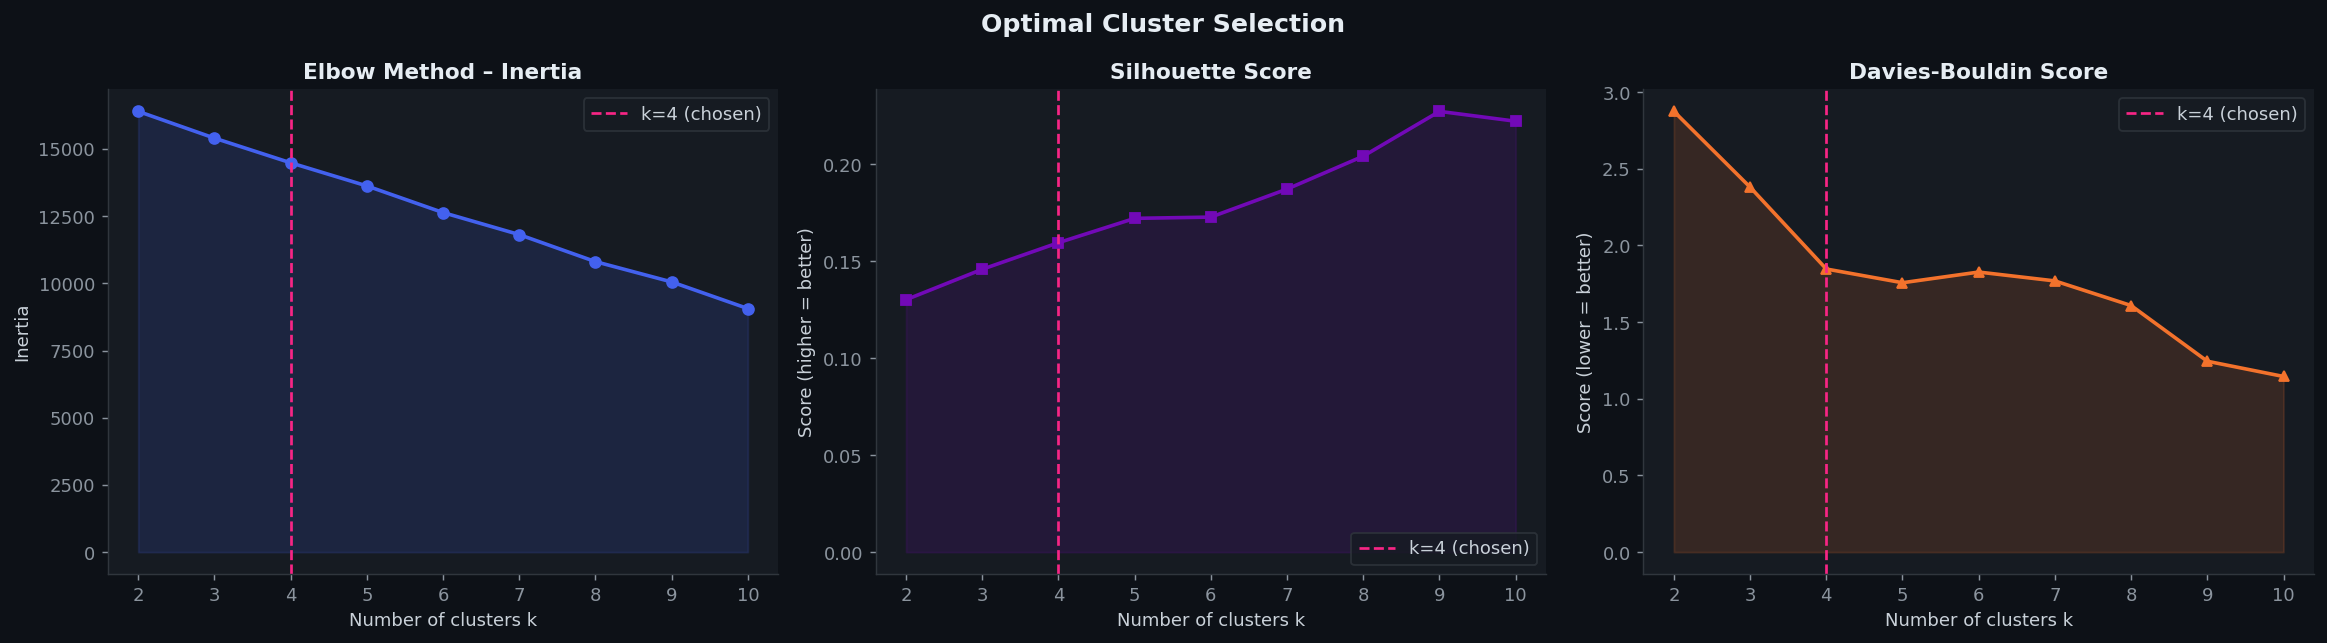

  ✓  saved 04_cluster_selection.png


In [18]:
# ─────────────────────────────────────────────────────────────
# 6. OPTIMAL CLUSTER SELECTION
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 5 — Optimal Cluster Count (Elbow + Silhouette)")
print("="*60)

K_range       = range(2, 11)
inertias      = []
silhouette_ks = []
db_scores     = []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_ks.append(silhouette_score(X, labels, sample_size=500, random_state=42))
    db_scores.append(davies_bouldin_score(X, labels))
    print(f"  k={k}  inertia={km.inertia_:,.0f}  sil={silhouette_ks[-1]:.4f}  DB={db_scores[-1]:.4f}")

# Elbow + Silhouette plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Optimal Cluster Selection", fontsize=14, fontweight="bold", color="#E6EDF3")

# Elbow
axes[0].plot(K_range, inertias, marker="o", color="#4361EE", linewidth=2)
axes[0].fill_between(K_range, inertias, alpha=0.15, color="#4361EE")
axes[0].axvline(4, color="#F72585", linestyle="--", linewidth=1.5, label="k=4 (chosen)")
axes[0].set_title("Elbow Method – Inertia", fontweight="bold")
axes[0].set_xlabel("Number of clusters k"); axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette
axes[1].plot(K_range, silhouette_ks, marker="s", color="#7209B7", linewidth=2)
axes[1].fill_between(K_range, silhouette_ks, alpha=0.15, color="#7209B7")
axes[1].axvline(4, color="#F72585", linestyle="--", linewidth=1.5, label="k=4 (chosen)")
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("Number of clusters k"); axes[1].set_ylabel("Score (higher = better)")
axes[1].legend()

# Davies-Bouldin
axes[2].plot(K_range, db_scores, marker="^", color="#F3722C", linewidth=2)
axes[2].fill_between(K_range, db_scores, alpha=0.15, color="#F3722C")
axes[2].axvline(4, color="#F72585", linestyle="--", linewidth=1.5, label="k=4 (chosen)")
axes[2].set_title("Davies-Bouldin Score", fontweight="bold")
axes[2].set_xlabel("Number of clusters k"); axes[2].set_ylabel("Score (lower = better)")
axes[2].legend()

fig.tight_layout()
plt.show()
save(fig, "04_cluster_selection")

In [19]:
# ─────────────────────────────────────────────────────────────
# 7. K-MEANS CLUSTERING  (k=4)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6 — K-Means Clustering  (k=4)")
print("="*60)

K_BEST = 4
kmeans = KMeans(n_clusters=K_BEST, init="k-means++", n_init=15, random_state=42)
df["kmeans_label"] = kmeans.fit_predict(X)

sil_final = silhouette_score(X, df["kmeans_label"])
print(f"  Final silhouette score: {sil_final:.4f}")
print(f"  Cluster sizes:\n{df['kmeans_label'].value_counts().sort_index()}")

# Map labels to semantic names
CLUSTER_NAMES = {0:"Global Investors",
                 1:"First-Time Buyers",
                 2:"Corporate Buyers",
                 3:"Luxury Investors"}

# Heuristic reassignment based on cluster centroids mean total_investment & age
centroids_df = (df.groupby("kmeans_label")[
    ["total_investment","age","num_properties","satisfaction_score"]
].mean())

print("\n  Cluster centroids (raw means):")
print(centroids_df.to_string())

# Sort clusters by total_investment descending to assign roles
order = centroids_df["total_investment"].sort_values(ascending=False).index.tolist()
ROLE  = ["Luxury Investors","Global Investors","Corporate Buyers","First-Time Buyers"]
label_map = {orig: role for orig, role in zip(order, ROLE)}
df["segment"] = df["kmeans_label"].map(label_map)

print("\n  Label mapping (by investment):", label_map)
print(f"  Segment distribution:\n{df['segment'].value_counts()}")


  STEP 6 — K-Means Clustering  (k=4)
  Final silhouette score: 0.1560
  Cluster sizes:
kmeans_label
0    458
1    316
2      7
3     74
Name: count, dtype: int64

  Cluster centroids (raw means):
              total_investment        age  num_properties  satisfaction_score
kmeans_label                                                                 
0                 1.265070e+06  52.775328        3.652838            3.024017
1                 1.260165e+06  53.620253        3.642405            3.091772
2                 1.568590e+06  48.628571        3.857143            2.571429
3                 1.272131e+06  49.812162        3.608108            2.878378

  Label mapping (by investment): {2: 'Luxury Investors', 3: 'Global Investors', 0: 'Corporate Buyers', 1: 'First-Time Buyers'}
  Segment distribution:
segment
Corporate Buyers     458
First-Time Buyers    316
Global Investors      74
Luxury Investors       7
Name: count, dtype: int64


In [20]:
# ─────────────────────────────────────────────────────────────
# 8. HIERARCHICAL CLUSTERING (validation)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 7 — Hierarchical Clustering (validation)")
print("="*60)

# Use a sample for dendrogram (full 2000 rows is messy)
sample_idx = np.random.RandomState(42).choice(len(X), size=300, replace=False)
X_sample   = X[sample_idx]
labels_sample = df["segment"].iloc[sample_idx].values

linked = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(18, 7))
fig.suptitle("Hierarchical Clustering – Dendrogram  (n=300 sample, Ward linkage)",
             fontsize=14, fontweight="bold", color="#E6EDF3")

dendrogram(linked, ax=ax, truncate_mode="lastp", p=30,
           color_threshold=linked[-3, 2],
           above_threshold_color="#8B949E",
           leaf_rotation=90, leaf_font_size=8,
           link_color_func=lambda k: PARCL_PALETTE[k % len(PARCL_PALETTE)])

ax.axhline(linked[-3, 2], color="#F72585", linestyle="--", linewidth=1.5,
           label=f"Cut → 4 clusters")
ax.set_xlabel("Sample index"); ax.set_ylabel("Distance")
ax.legend()

fig.tight_layout()
save(fig, "05_dendrogram")

# Hierarchical cluster labels on full data for comparison
hc = AgglomerativeClustering(n_clusters=K_BEST, linkage="ward")
df["hc_label"] = hc.fit_predict(X)

agree = (df["kmeans_label"] == df["hc_label"]).mean()
print(f"  Raw label agreement K-Means vs HC: {agree:.2%}  (permutation-sensitive, informational only)")


  STEP 7 — Hierarchical Clustering (validation)
  ✓  saved 05_dendrogram.png
  Raw label agreement K-Means vs HC: 16.73%  (permutation-sensitive, informational only)



  STEP 8 — PCA Cluster Visualisation


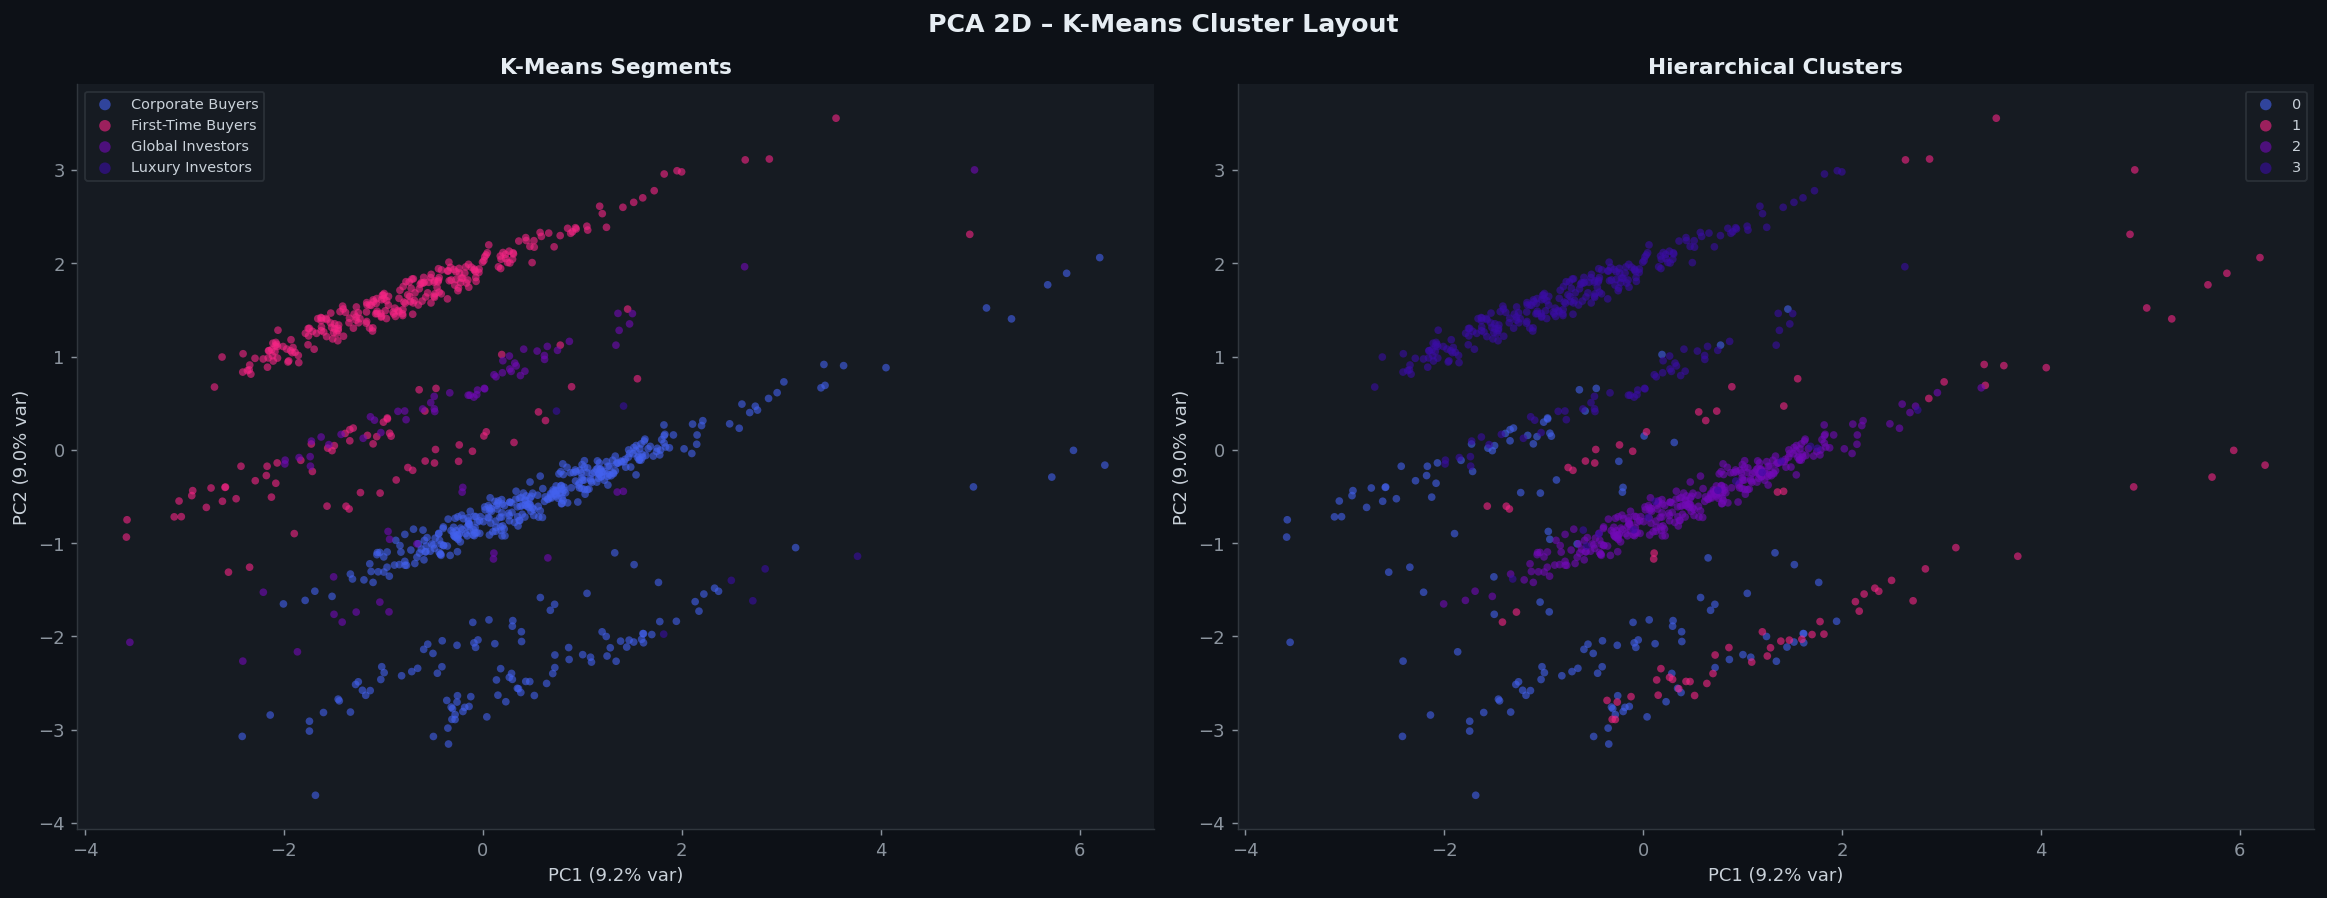

  ✓  saved 06_pca_clusters.png


In [21]:
# ─────────────────────────────────────────────────────────────
# 9. PCA 2D VISUALISATION
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 8 — PCA Cluster Visualisation")
print("="*60)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

seg_colors = [PARCL_PALETTE[i] for i in range(4)]
seg_order  = ["Global Investors","First-Time Buyers","Corporate Buyers","Luxury Investors"]
color_map  = dict(zip(seg_order, seg_colors))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("PCA 2D – K-Means Cluster Layout", fontsize=14, fontweight="bold", color="#E6EDF3")

for ax, col, title in zip(axes, ["segment","hc_label"],
                           ["K-Means Segments","Hierarchical Clusters"]):
    unique_vals = df[col].unique()
    palette     = PARCL_PALETTE[:len(unique_vals)]
    for idx, val in enumerate(sorted(unique_vals, key=str)):
        mask = df[col]==val
        ax.scatter(df.loc[mask,"pca1"], df.loc[mask,"pca2"],
                   c=palette[idx], label=str(val), alpha=0.6, s=18, edgecolors="none")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    ax.legend(fontsize=8, markerscale=1.5)

fig.tight_layout()
plt.show()
save(fig, "06_pca_clusters")


  STEP 9 — Cluster Interpretation
                     age  satisfaction_score  num_properties  total_investment  avg_unit_area  loan_applied_enc  acq_purpose_enc  client_type_enc
segment                                                                                                                                          
Corporate Buyers   52.78                3.02            3.65        1265070.09        1150.56              0.38             0.31             0.04
First-Time Buyers  53.62                3.09            3.64        1260165.27        1151.48              0.36             0.32             0.06
Global Investors   49.81                2.88            3.61        1272131.40        1165.88              0.38             0.34             0.03
Luxury Investors   48.63                2.57            3.86        1568590.42        1369.04              0.29             0.14             0.00


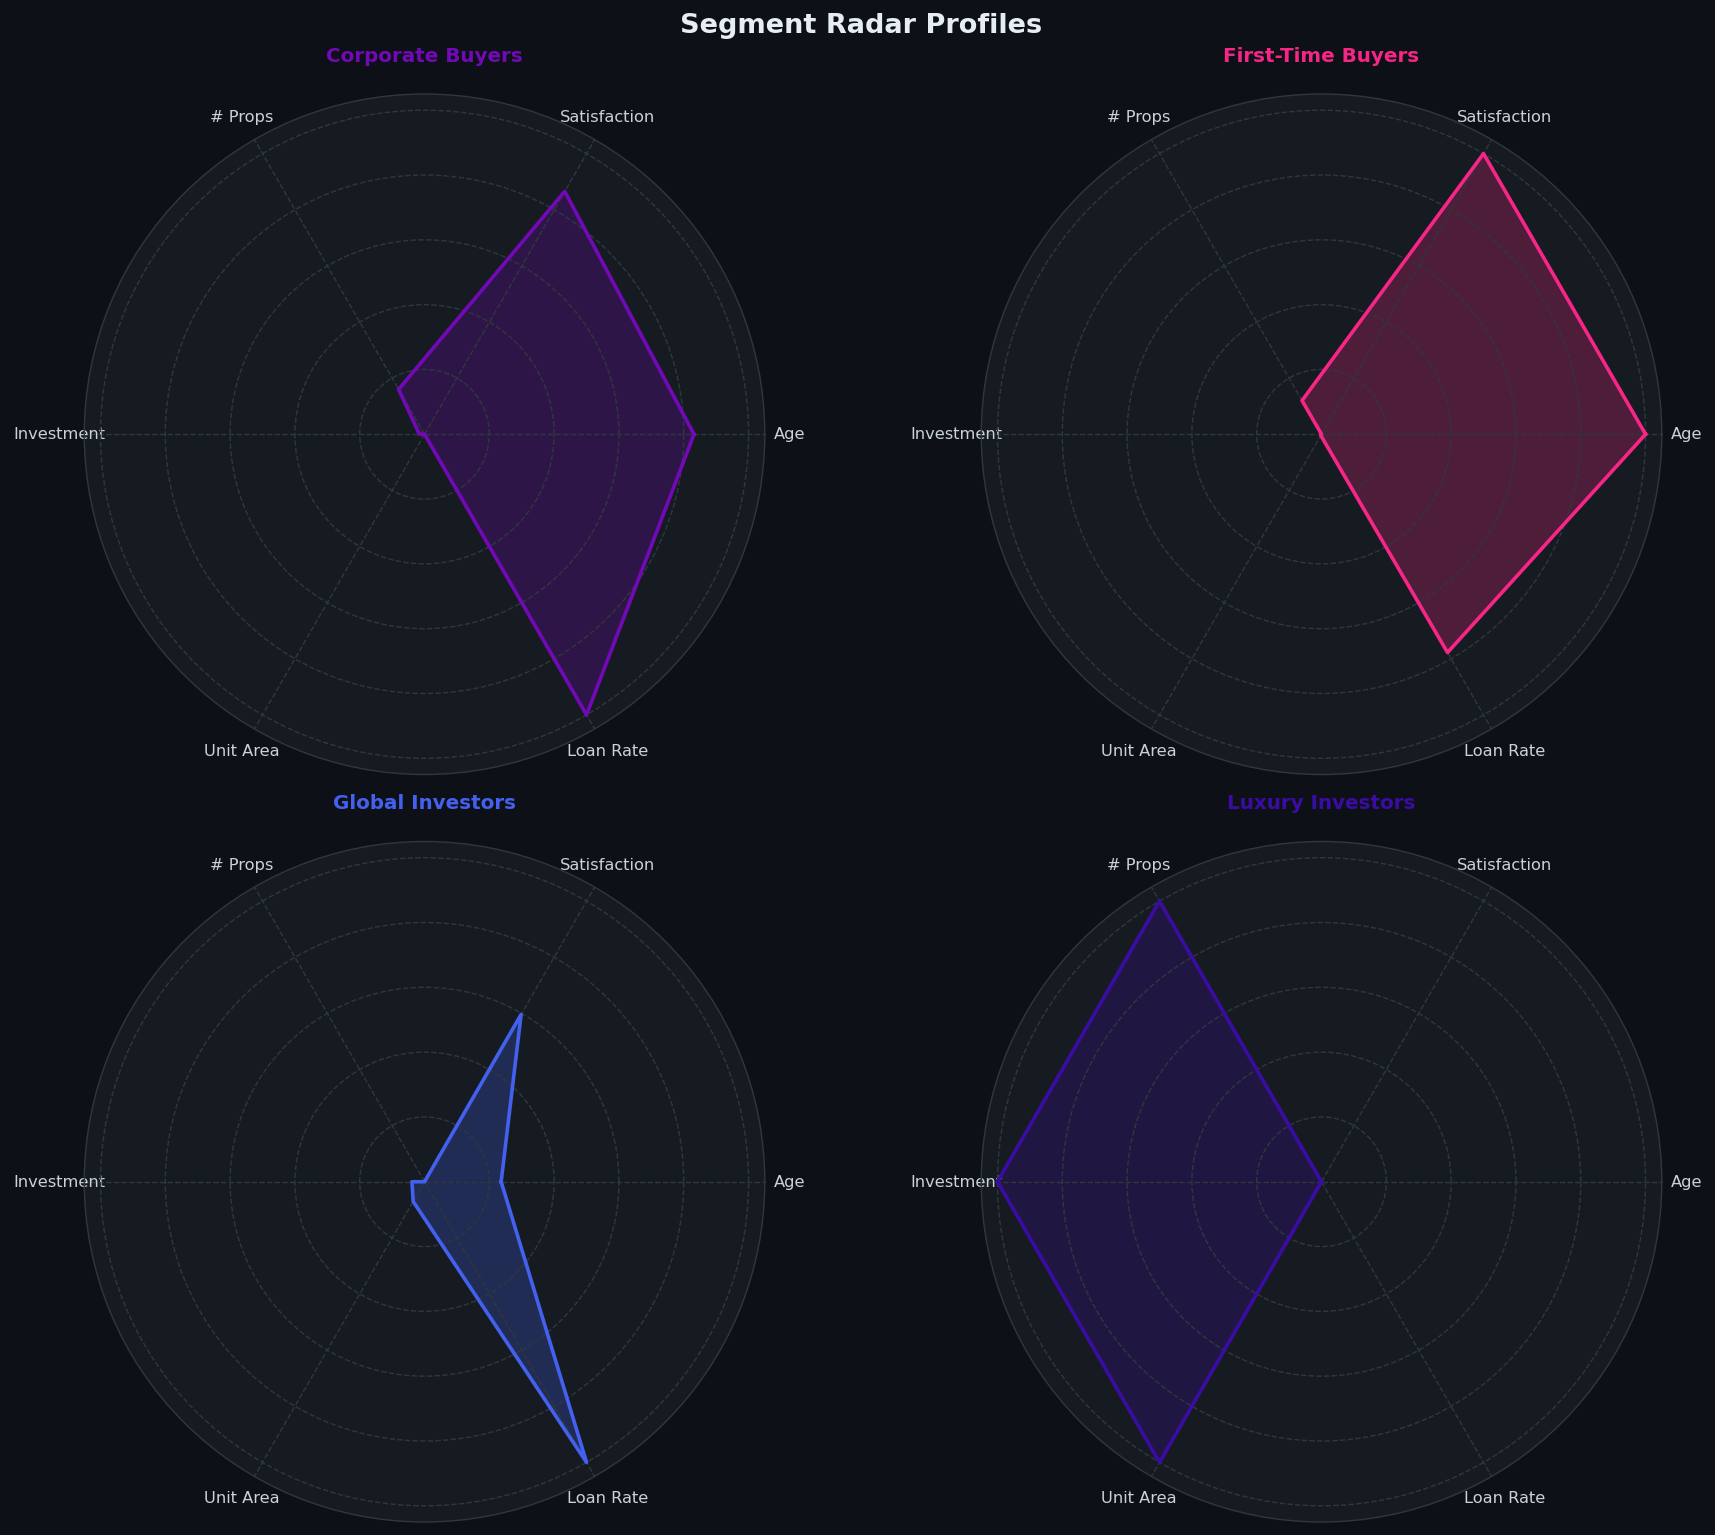

  ✓  saved 07_radar_profiles.png


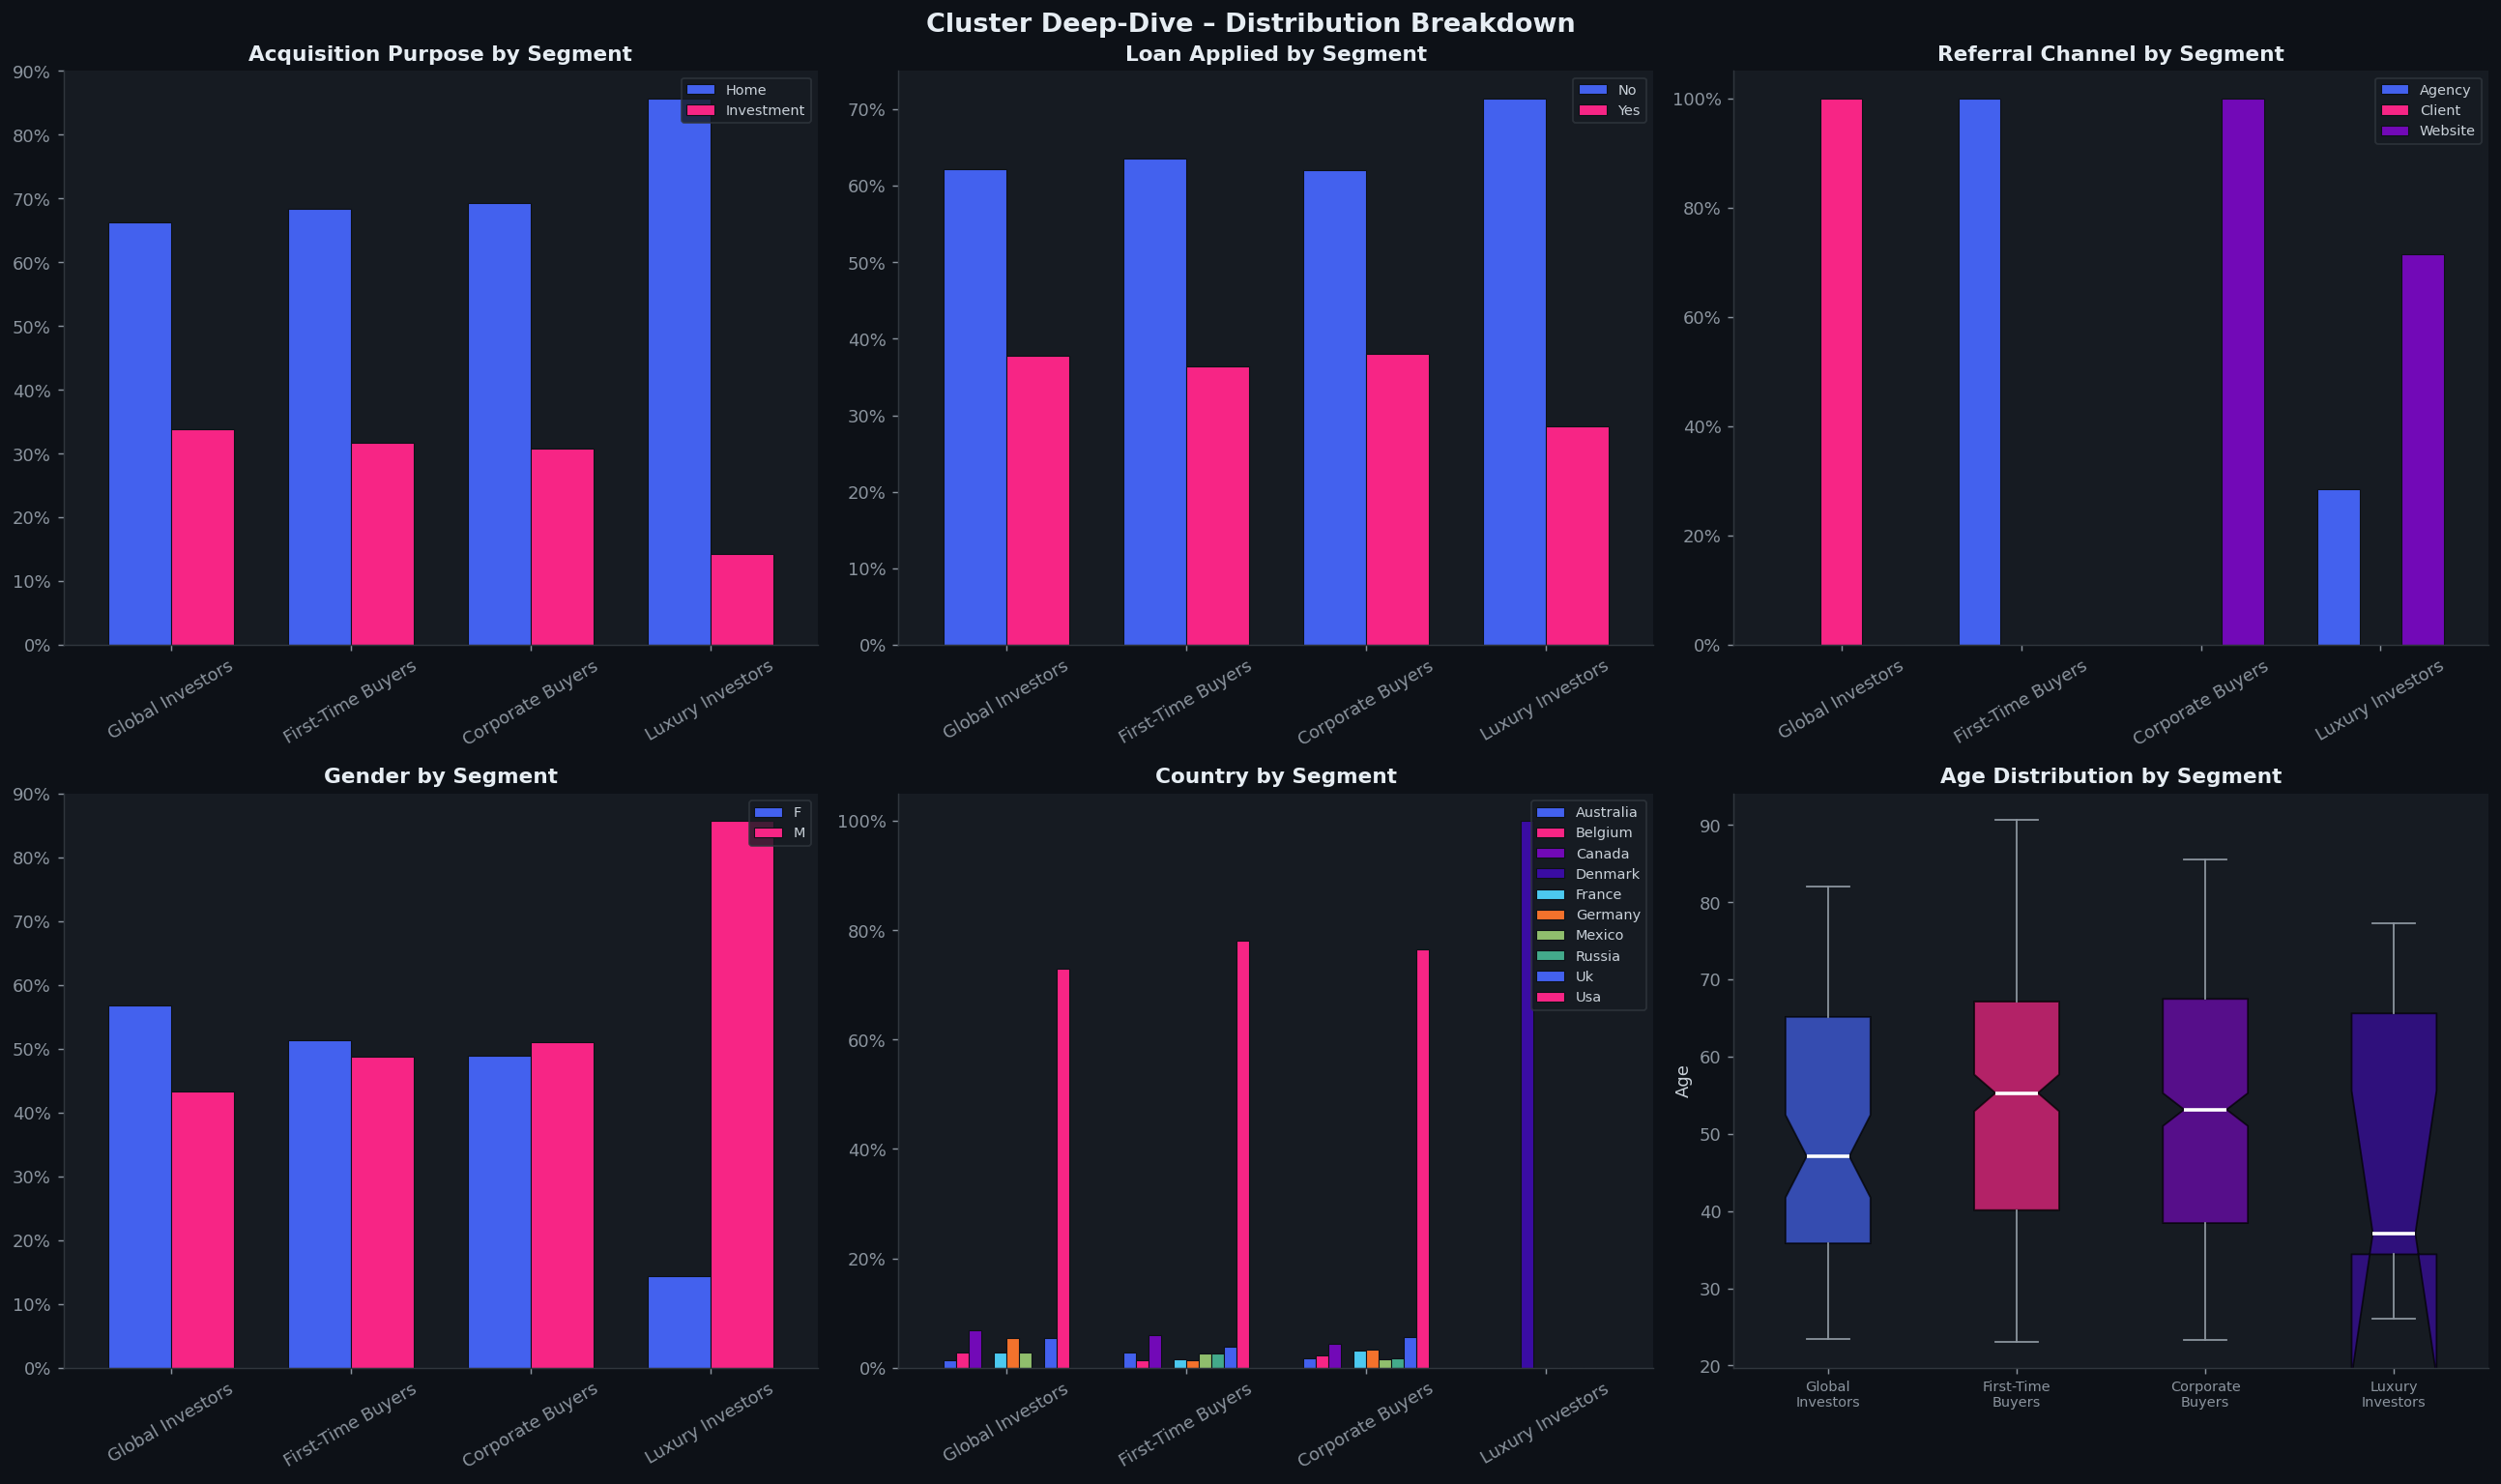

  ✓  saved 08_segment_breakdown.png


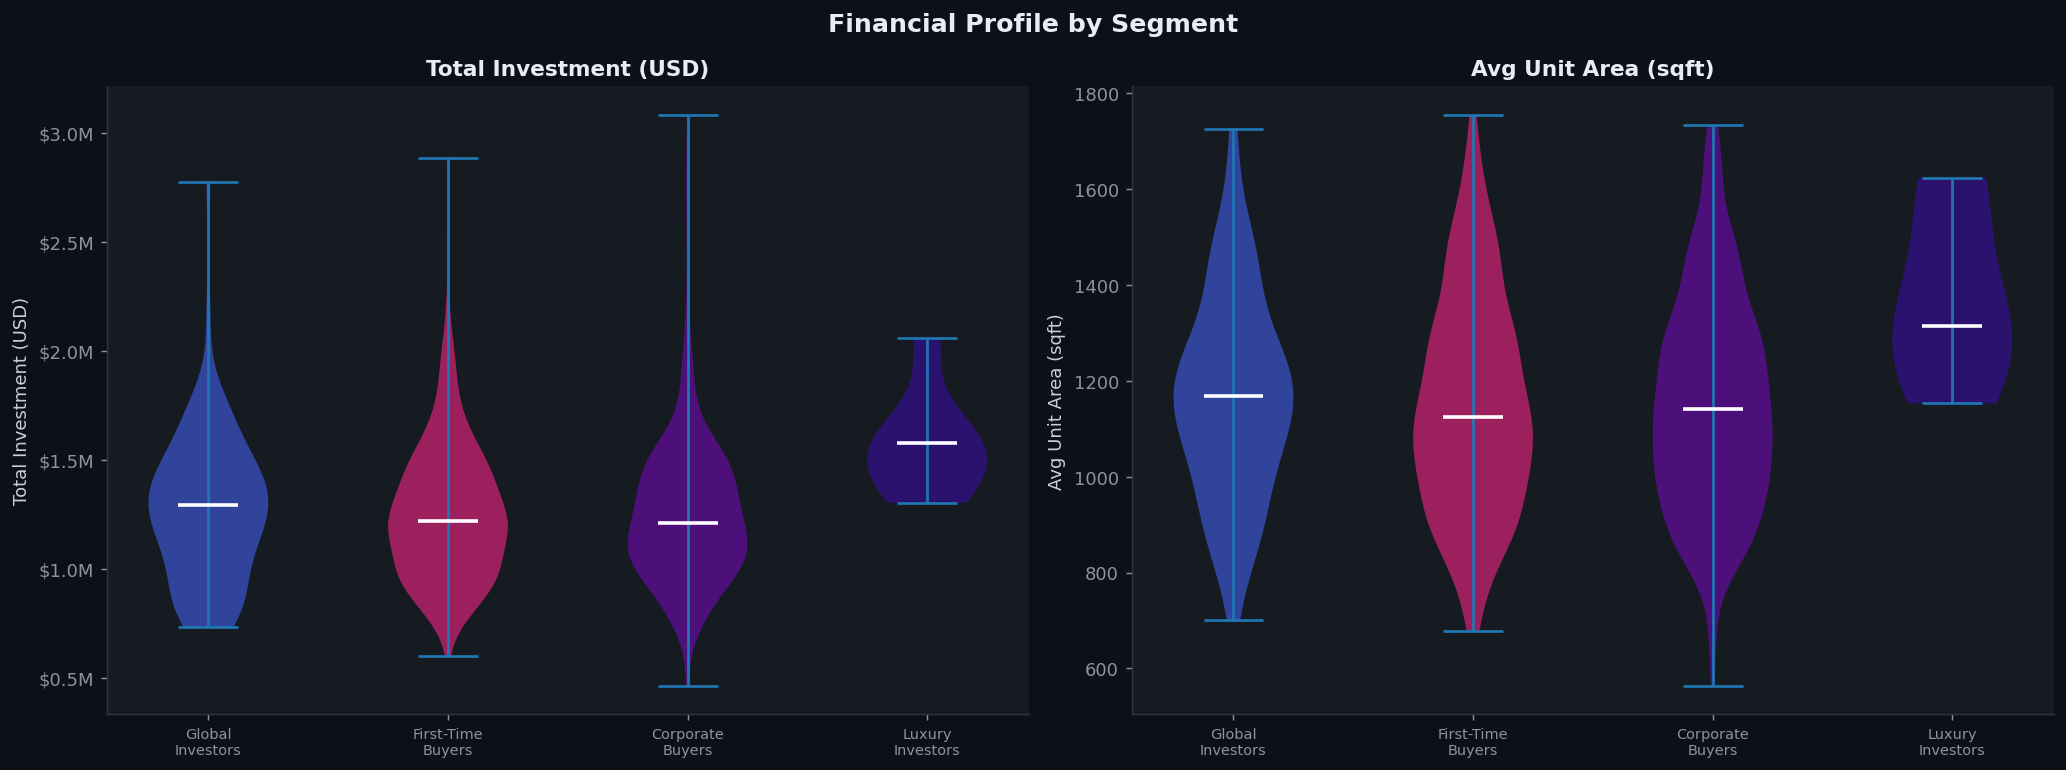

  ✓  saved 09_financial_profiles.png


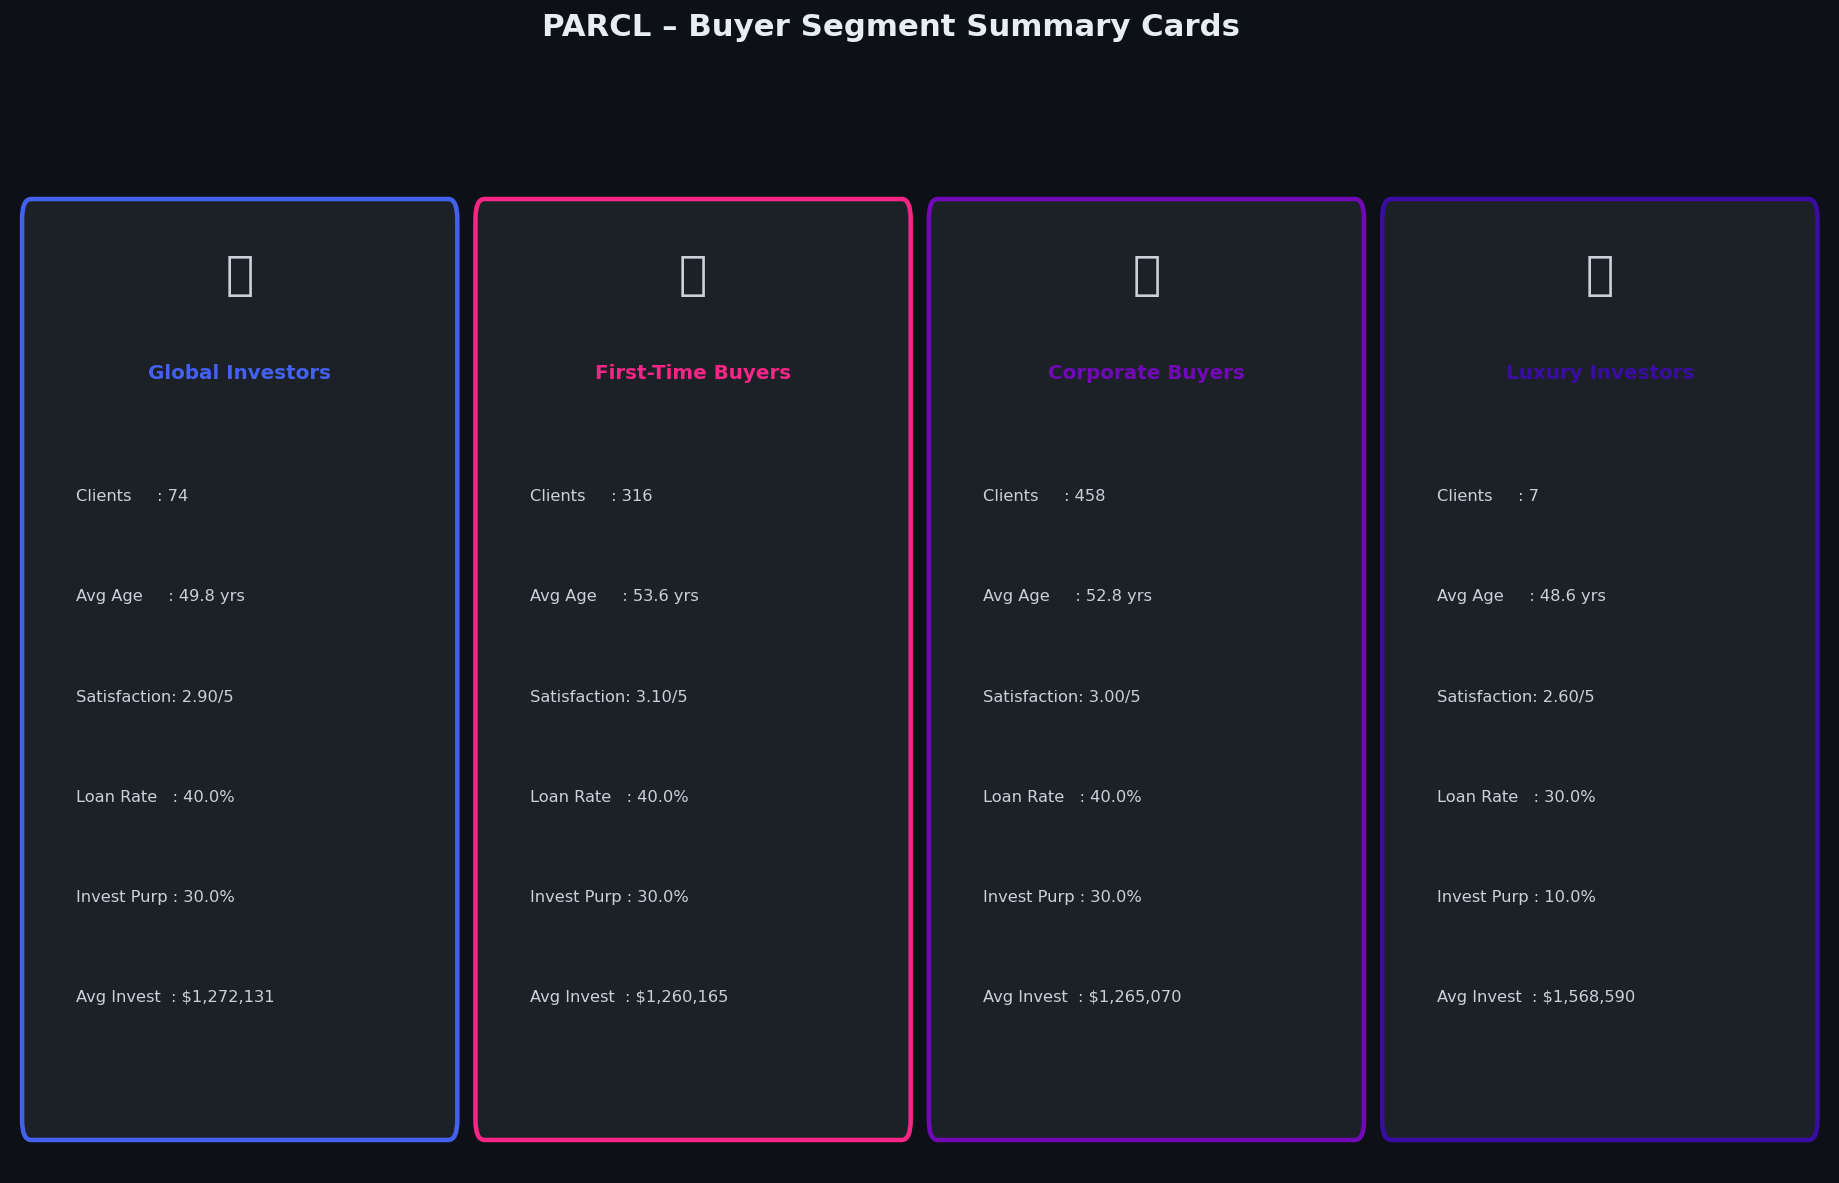

  ✓  saved 10_segment_cards.png


In [23]:
# ─────────────────────────────────────────────────────────────
# 10. CLUSTER INTERPRETATION & PROFILE CARDS
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 9 — Cluster Interpretation")
print("="*60)

profile_cols = ["age","satisfaction_score","num_properties","total_investment","avg_unit_area"]

# Add loan/purpose/type as encoded columns from X_raw aligned to df
df_enc = df.copy()
df_enc["loan_applied_enc"] = (df["loan_applied"] == "Yes").astype(int)
df_enc["acq_purpose_enc"]  = (df["acquisition_purpose"] == "Investment").astype(int)
df_enc["client_type_enc"]  = (df["client_type"] == "Company").astype(int)

profiles = df_enc.groupby("segment")[
    profile_cols + ["loan_applied_enc","acq_purpose_enc","client_type_enc"]
].mean().round(2)
print(profiles.to_string())

# ── 10A. Radar chart per segment ──────────────────────────────
from matplotlib.patches import FancyBboxPatch

# Normalise profiles to 0-1 for radar
radar_cols    = ["age","satisfaction_score","num_properties","total_investment","avg_unit_area","loan_applied_enc"]
radar_labels  = ["Age","Satisfaction","# Props","Investment","Unit Area","Loan Rate"]

prof_norm = profiles[radar_cols].copy()
for c in radar_cols:
    rng = prof_norm[c].max() - prof_norm[c].min()
    prof_norm[c] = (prof_norm[c] - prof_norm[c].min()) / (rng if rng else 1)

N = len(radar_cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                         subplot_kw=dict(polar=True))
fig.suptitle("Segment Radar Profiles", fontsize=15, fontweight="bold", color="#E6EDF3")
fig.patch.set_facecolor("#0D1117")

for ax, (seg, row) in zip(axes.flat, prof_norm.iterrows()):
    vals = row.tolist() + [row.iloc[0]]
    c    = color_map.get(seg, "#4361EE")

    ax.set_facecolor("#161B22")
    ax.plot(angles, vals, color=c, linewidth=2)
    ax.fill(angles, vals, color=c, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9, color="#C9D1D9")
    ax.set_yticklabels([])
    ax.set_title(seg, fontsize=11, fontweight="bold", color=c, pad=18)
    ax.grid(color="#30363D")
    ax.spines["polar"].set_color("#30363D")

fig.tight_layout()
plt.show()
save(fig, "07_radar_profiles")

# ── 10B. Segment breakdown bar charts ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Cluster Deep-Dive – Distribution Breakdown", fontsize=15,
             fontweight="bold", color="#E6EDF3")

segs      = df["segment"].unique()
seg_pal   = [color_map.get(s, "#4361EE") for s in seg_order]

def seg_bar(ax, col, title, pct=False):
    ct = df.groupby("segment")[col].value_counts(normalize=pct).unstack(fill_value=0)
    ct = ct.reindex(index=[s for s in seg_order if s in ct.index])
    ct.plot(kind="bar", ax=ax, color=PARCL_PALETTE[:ct.shape[1]],
            edgecolor="#0D1117", linewidth=0.6, width=0.7)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8, loc="upper right")
    if pct:
        ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

seg_bar(axes[0,0], "acquisition_purpose", "Acquisition Purpose by Segment", pct=True)
seg_bar(axes[0,1], "loan_applied",        "Loan Applied by Segment",        pct=True)
seg_bar(axes[0,2], "referral_channel",    "Referral Channel by Segment",    pct=True)
seg_bar(axes[1,0], "gender",              "Gender by Segment",              pct=True)
seg_bar(axes[1,1], "country",             "Country by Segment",             pct=True)

# Age boxplot
bp_data   = [df[df["segment"]==s]["age"].dropna().values for s in seg_order]
bplot     = axes[1,2].boxplot(bp_data, patch_artist=True, notch=True,
                               medianprops=dict(color="white",linewidth=2),
                               whiskerprops=dict(color="#8B949E"),
                               capprops=dict(color="#8B949E"),
                               flierprops=dict(marker="o",markersize=2,alpha=0.4,
                                               markerfacecolor="#F72585"))
for patch, c in zip(bplot["boxes"], seg_pal):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,2].set_xticklabels([s.replace(" ","\n") for s in seg_order], fontsize=8)
axes[1,2].set_title("Age Distribution by Segment", fontweight="bold")
axes[1,2].set_ylabel("Age")

fig.tight_layout()
plt.show()
save(fig, "08_segment_breakdown")

# ── 10C. Investment violin ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Financial Profile by Segment", fontsize=14, fontweight="bold", color="#E6EDF3")

inv_buyers = df[df["total_investment"]>0].copy()

for ax, col, ylabel in zip(axes,
                            ["total_investment","avg_unit_area"],
                            ["Total Investment (USD)","Avg Unit Area (sqft)"]):
    parts = ax.violinplot(
        [inv_buyers[inv_buyers["segment"]==s][col].values for s in seg_order if s in inv_buyers["segment"].values],
        showmedians=True, showextrema=True
    )
    for pc, c in zip(parts["bodies"], seg_pal):
        pc.set_facecolor(c); pc.set_alpha(0.6)
    parts["cmedians"].set_colors("white"); parts["cmedians"].set_linewidth(2)
    ax.set_xticks(range(1, len(seg_order)+1))
    ax.set_xticklabels([s.replace(" ","\n") for s in seg_order], fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight="bold")
    if col=="total_investment":
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))

fig.tight_layout()
plt.show()
save(fig, "09_financial_profiles")


# ── 10D. Summary segment card visual ─────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 4); ax.set_ylim(0, 1)
ax.axis("off")
fig.suptitle("PARCL – Buyer Segment Summary Cards",
             fontsize=17, fontweight="bold", color="#E6EDF3", y=1.0)
fig.patch.set_facecolor("#0D1117")

seg_stats = df_enc.groupby("segment").agg(
    count          = ("client_id","count"),
    avg_age        = ("age","mean"),
    avg_satisfaction = ("satisfaction_score","mean"),
    loan_rate      = ("loan_applied_enc","mean"),
    invest_pct     = ("acq_purpose_enc","mean"),
    total_inv      = ("total_investment","mean"),
).round(1)

icons = {"Global Investors":"🌍","First-Time Buyers":"🏠","Corporate Buyers":"🏢","Luxury Investors":"💎"}

for i, seg in enumerate(seg_order):
    x0 = i * 1.0 + 0.04
    row = seg_stats.loc[seg] if seg in seg_stats.index else None

    # Card background
    rect = FancyBboxPatch((x0, 0.05), 0.92, 0.9,
                           boxstyle="round,pad=0.02",
                           facecolor="#1C2128", edgecolor=color_map.get(seg,"#4361EE"),
                           linewidth=2.5, zorder=2)
    ax.add_patch(rect)

    c = color_map.get(seg,"#4361EE")
    ax.text(x0+0.46, 0.88, icons.get(seg,""), ha="center", fontsize=26, zorder=3)
    ax.text(x0+0.46, 0.79, seg, ha="center", fontsize=11, fontweight="bold",
            color=c, zorder=3)

    if row is not None:
        lines = [
            f"Clients     : {int(row['count']):,}",
            f"Avg Age     : {row['avg_age']:.1f} yrs",
            f"Satisfaction: {row['avg_satisfaction']:.2f}/5",
            f"Loan Rate   : {row['loan_rate']*100:.1f}%",
            f"Invest Purp : {row['invest_pct']*100:.1f}%",
            f"Avg Invest  : ${row['total_inv']:,.0f}",
        ]
        for j, line in enumerate(lines):
            ax.text(x0+0.1, 0.68 - j*0.1, line, fontsize=9,
                    color="#C9D1D9", zorder=3, va="top")

plt.show()
save(fig, "10_segment_cards")